In [2]:
!pip install pingouin

Defaulting to user installation because normal site-packages is not writeable


#Load your data into new notebook

In [3]:
import pandas as pd

listings = pd.read_parquet("../data/interim/listings_final2_silver.parquet")
calendar = pd.read_parquet("../data/interim/calendar_silver.parquet")

print(listings.shape, calendar.shape)

(30259, 95) (11152576, 5)


#H1: Entire-home listings command significantly higher prices than private rooms
#Null hypothesis (H0): No difference in mean price between entire-home/apt listings and private-room listings.
#Alternative (H1): Entire-home/apt listings have significantly higher mean price than private-room listings.

#Prepare the two groups and check assumptions

In [4]:
import scipy.stats as stats
import numpy as np

entire = listings[listings['room_type'] == 'Entire home/apt']['price'].dropna()
private = listings[listings['room_type'] == 'Private room']['price'].dropna()

print(f"Entire home/apt: n={len(entire)}, mean=${entire.mean():.2f}, std=${entire.std():.2f}")
print(f"Private room: n={len(private)}, mean=${private.mean():.2f}, std=${private.std():.2f}")

# Check normality (Shapiro-Wilk on a sample, since full data is too large for the test)
print("\nNormality check (Shapiro-Wilk, sample of 5000):")
print("Entire home:", stats.shapiro(entire.sample(min(5000, len(entire)), random_state=42)))
print("Private room:", stats.shapiro(private.sample(min(5000, len(private)), random_state=42)))

# Check equal variance (Levene's test)
print("\nLevene's test for equal variance:")
print(stats.levene(entire, private))

Entire home/apt: n=11537, mean=$331.41, std=$534.75
Private room: n=9306, mean=$191.78, std=$448.62

Normality check (Shapiro-Wilk, sample of 5000):
Entire home: ShapiroResult(statistic=np.float64(0.37320648306467946), pvalue=np.float64(4.116040010343976e-85))
Private room: ShapiroResult(statistic=np.float64(0.18951427725827305), pvalue=np.float64(6.103894791828309e-91))

Levene's test for equal variance:
LeveneResult(statistic=np.float64(84.064240551091), pvalue=np.float64(5.2225376306066874e-20))


#Mann-Whitney U test + effect size

In [5]:
# Mann-Whitney U test (non-parametric alternative to independent t-test)
u_stat, p_value = stats.mannwhitneyu(entire, private, alternative='greater')
print(f"Mann-Whitney U statistic: {u_stat:.1f}")
print(f"p-value: {p_value:.6f}")

# Effect size: rank-biserial correlation (appropriate for Mann-Whitney U)
n1, n2 = len(entire), len(private)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {rank_biserial:.4f}")

# Also report median difference (more meaningful than mean given skew)
print(f"\nMedian price - Entire home/apt: ${entire.median():.2f}")
print(f"Median price - Private room: ${private.median():.2f}")

Mann-Whitney U statistic: 80511214.5
p-value: 0.000000
Rank-biserial correlation (effect size): -0.4998

Median price - Entire home/apt: $222.87
Median price - Private room: $102.97


#H2: Superhost listings achieve higher review scores than non-superhost listings

In [6]:
superhost = listings[listings['host_is_superhost'] == 't']['review_scores_rating'].dropna()
non_superhost = listings[listings['host_is_superhost'] == 'f']['review_scores_rating'].dropna()

print(f"Superhost: n={len(superhost)}, mean={superhost.mean():.3f}, std={superhost.std():.3f}")
print(f"Non-superhost: n={len(non_superhost)}, mean={non_superhost.mean():.3f}, std={non_superhost.std():.3f}")

print("\nNormality check:")
print("Superhost:", stats.shapiro(superhost.sample(min(5000, len(superhost)), random_state=42)))
print("Non-superhost:", stats.shapiro(non_superhost.sample(min(5000, len(non_superhost)), random_state=42)))

print("\nLevene's test:")
print(stats.levene(superhost, non_superhost))

Superhost: n=6066, mean=4.858, std=0.203
Non-superhost: n=15385, mean=4.687, std=0.501

Normality check:
Superhost: ShapiroResult(statistic=np.float64(0.6571503901984582), pvalue=np.float64(3.336987867866606e-72))
Non-superhost: ShapiroResult(statistic=np.float64(0.5945052175886095), pvalue=np.float64(1.1007202996319398e-75))

Levene's test:
LeveneResult(statistic=np.float64(733.1609270790741), pvalue=np.float64(8.563186285397748e-159))


#Mann-Whitney U + effect size for H2

In [7]:
u_stat2, p_value2 = stats.mannwhitneyu(superhost, non_superhost, alternative='greater')
print(f"Mann-Whitney U statistic: {u_stat2:.1f}")
print(f"p-value: {p_value2:.6f}")

n1, n2 = len(superhost), len(non_superhost)
rank_biserial2 = 1 - (2 * u_stat2) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {rank_biserial2:.4f}")

print(f"\nMedian rating - Superhost: {superhost.median():.3f}")
print(f"Median rating - Non-superhost: {non_superhost.median():.3f}")

Mann-Whitney U statistic: 55693276.5
p-value: 0.000000
Rank-biserial correlation (effect size): -0.1935

Median rating - Superhost: 4.910
Median rating - Non-superhost: 4.820


#H3: Listings with 10+ reviews have significantly different prices than listings with fewer reviews

In [8]:
high_reviews = listings[listings['review_count_actual'] >= 10]['price'].dropna()
low_reviews = listings[listings['review_count_actual'] < 10]['price'].dropna()

print(f"10+ reviews: n={len(high_reviews)}, mean=${high_reviews.mean():.2f}, std=${high_reviews.std():.2f}")
print(f"<10 reviews: n={len(low_reviews)}, mean=${low_reviews.mean():.2f}, std=${low_reviews.std():.2f}")

print("\nNormality check:")
print("10+ reviews:", stats.shapiro(high_reviews.sample(min(5000, len(high_reviews)), random_state=42)))
print("<10 reviews:", stats.shapiro(low_reviews.sample(min(5000, len(low_reviews)), random_state=42)))

print("\nLevene's test:")
print(stats.levene(high_reviews, low_reviews))

10+ reviews: n=9467, mean=$250.84, std=$340.28
<10 reviews: n=5971, mean=$237.41, std=$423.22

Normality check:
10+ reviews: ShapiroResult(statistic=np.float64(0.41761576156686664), pvalue=np.float64(1.757382222621204e-83))
<10 reviews: ShapiroResult(statistic=np.float64(0.2923521232229094), pvalue=np.float64(7.716172380719782e-88))

Levene's test:
LeveneResult(statistic=np.float64(1.154908652666273), pvalue=np.float64(0.2825407471177887))


#Mann-Whitney U

In [9]:
u_stat3, p_value3 = stats.mannwhitneyu(high_reviews, low_reviews, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat3:.1f}")
print(f"p-value: {p_value3:.6f}")

n1, n2 = len(high_reviews), len(low_reviews)
rank_biserial3 = 1 - (2 * u_stat3) / (n1 * n2)
print(f"Rank-biserial correlation (effect size): {rank_biserial3:.4f}")

print(f"\nMedian price - 10+ reviews: ${high_reviews.median():.2f}")
print(f"Median price - <10 reviews: ${low_reviews.median():.2f}")

Mann-Whitney U statistic: 31043620.0
p-value: 0.000000
Rank-biserial correlation (effect size): -0.0984

Median price - 10+ reviews: $174.69
Median price - <10 reviews: $159.34


#H4: Neighbourhood average prices differ significantly (ANOVA across neighbourhood groups)

In [10]:
groups = [listings[listings['neighbourhood_group_cleansed'] == b]['price'].dropna()
          for b in listings['neighbourhood_group_cleansed'].unique()]

# Normality check per group
for name, g in zip(listings['neighbourhood_group_cleansed'].unique(), groups):
    stat, p = stats.shapiro(g.sample(min(5000, len(g)), random_state=42))
    print(f"{name}: n={len(g)}, Shapiro p={p:.2e}")

# Levene's test across all 5 groups
print("\nLevene's test across boroughs:")
print(stats.levene(*groups))

Brooklyn: n=7239, Shapiro p=2.10e-84
Manhattan: n=9539, Shapiro p=2.48e-88
Queens: n=3615, Shapiro p=1.41e-81
Bronx: n=826, Shapiro p=1.37e-51
Staten Island: n=296, Shapiro p=3.26e-25

Levene's test across boroughs:
LeveneResult(statistic=np.float64(88.49001243509102), pvalue=np.float64(1.0172375955982628e-74))


#Kruskal-Wallis + effect size (eta-squared equivalent)

In [11]:
h_stat, p_value4 = stats.kruskal(*groups)
print(f"Kruskal-Wallis H statistic: {h_stat:.2f}")
print(f"p-value: {p_value4:.6f}")

# Effect size for Kruskal-Wallis: epsilon-squared
n_total = sum(len(g) for g in groups)
k = len(groups)
epsilon_sq = (h_stat - k + 1) / (n_total - k)
print(f"Epsilon-squared (effect size): {epsilon_sq:.4f}")

# Median price by borough for interpretation
print("\nMedian price by borough:")
print(listings.groupby('neighbourhood_group_cleansed')['price'].median().sort_values(ascending=False))

Kruskal-Wallis H statistic: 2803.97
p-value: 0.000000
Epsilon-squared (effect size): 0.1302

Median price by borough:
neighbourhood_group_cleansed
Manhattan        240.560
Brooklyn         151.440
Queens           120.040
Staten Island    107.295
Bronx            106.385
Name: price, dtype: float64


#H5 (reframed): Weekend listings show significantly different availability/booking rates than weekday listings

#Build the comparison

In [12]:
calendar['day_of_week'] = calendar['date'].dt.dayofweek  # 0=Mon ... 6=Sun
calendar['is_weekend'] = calendar['day_of_week'].isin([5, 6])  # Sat, Sun
calendar['is_booked'] = calendar['available'] == 'f'  # 'f' = unavailable = booked/blocked

weekend_booked_rate = calendar[calendar['is_weekend']]['is_booked'].mean()
weekday_booked_rate = calendar[~calendar['is_weekend']]['is_booked'].mean()

print(f"Weekend booked rate: {weekend_booked_rate:.4f}")
print(f"Weekday booked rate: {weekday_booked_rate:.4f}")

n_weekend = calendar['is_weekend'].sum()
n_weekday = (~calendar['is_weekend']).sum()
print(f"\nn (weekend rows): {n_weekend:,}")
print(f"n (weekday rows): {n_weekday:,}")

Weekend booked rate: 0.4897
Weekday booked rate: 0.4876

n (weekend rows): 3,192,264
n (weekday rows): 7,960,312


#Statistical test

In [13]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [14]:
from statsmodels.stats.proportion import proportions_ztest

count = [calendar[calendar['is_weekend']]['is_booked'].sum(),
         calendar[~calendar['is_weekend']]['is_booked'].sum()]
nobs = [n_weekend, n_weekday]

z_stat, p_value5 = proportions_ztest(count, nobs)
print(f"Z statistic: {z_stat:.3f}")
print(f"p-value: {p_value5:.6f}")

# Effect size: Cohen's h for proportions
import numpy as np
p1, p2 = weekend_booked_rate, weekday_booked_rate
cohens_h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
print(f"Cohen's h (effect size): {cohens_h:.4f}")

Z statistic: 6.263
p-value: 0.000000
Cohen's h (effect size): 0.0041


#5.2  Confidence Intervals & Effect Sizes

#Confidence intervals for mean prices by neighbourhood and room type

In [15]:
import numpy as np

def bootstrap_ci(data, n_boot=2000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    boot_means = np.array([
        rng.choice(data, size=len(data), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100 - (100-ci)/2)
    return data.mean(), lower, upper

# By room type
print("=== 95% CI for mean price by room type ===")
for rtype in listings['room_type'].unique():
    data = listings[listings['room_type'] == rtype]['price'].dropna()
    mean, lo, hi = bootstrap_ci(data)
    print(f"{rtype}: mean=${mean:.2f}, 95% CI=[${lo:.2f}, ${hi:.2f}], n={len(data)}")

=== 95% CI for mean price by room type ===
Private room: mean=$191.78, 95% CI=[$183.15, $201.06], n=9306
Entire home/apt: mean=$331.41, 95% CI=[$321.77, $341.65], n=11537
Hotel room: mean=$721.57, 95% CI=[$624.51, $839.87], n=480
Shared room: mean=$164.39, 95% CI=[$124.99, $210.43], n=192


In [16]:
# By borough (neighbourhood_group)
print("\n=== 95% CI for mean price by borough ===")
for borough in listings['neighbourhood_group_cleansed'].unique():
    data = listings[listings['neighbourhood_group_cleansed'] == borough]['price'].dropna()
    mean, lo, hi = bootstrap_ci(data)
    print(f"{borough}: mean=${mean:.2f}, 95% CI=[${lo:.2f}, ${hi:.2f}], n={len(data)}")


=== 95% CI for mean price by borough ===
Brooklyn: mean=$213.22, 95% CI=[$206.78, $220.24], n=7239
Manhattan: mean=$381.79, 95% CI=[$368.01, $397.05], n=9539
Queens: mean=$174.85, 95% CI=[$164.58, $186.93], n=3615
Bronx: mean=$152.78, 95% CI=[$131.00, $186.54], n=826
Staten Island: mean=$143.13, 95% CI=[$129.01, $158.01], n=296


##5.3  Correla on & Driver Analysis

#Correlation matrix across numerical features

In [17]:
numeric_cols = [
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
    'availability_365', 'number_of_reviews', 'review_scores_rating',
    'occupancy_rate', 'host_tenure_years_est', 'review_frequency_per_month'
]

corr_matrix = listings[numeric_cols].corr()
print(corr_matrix['price'].sort_values(ascending=False))

price                         1.000000
accommodates                  0.338161
bathrooms                     0.315908
bedrooms                      0.258095
review_frequency_per_month    0.061750
availability_365              0.056168
review_scores_rating          0.041456
number_of_reviews            -0.025051
occupancy_rate               -0.056146
host_tenure_years_est        -0.078436
minimum_nights               -0.146677
Name: price, dtype: float64


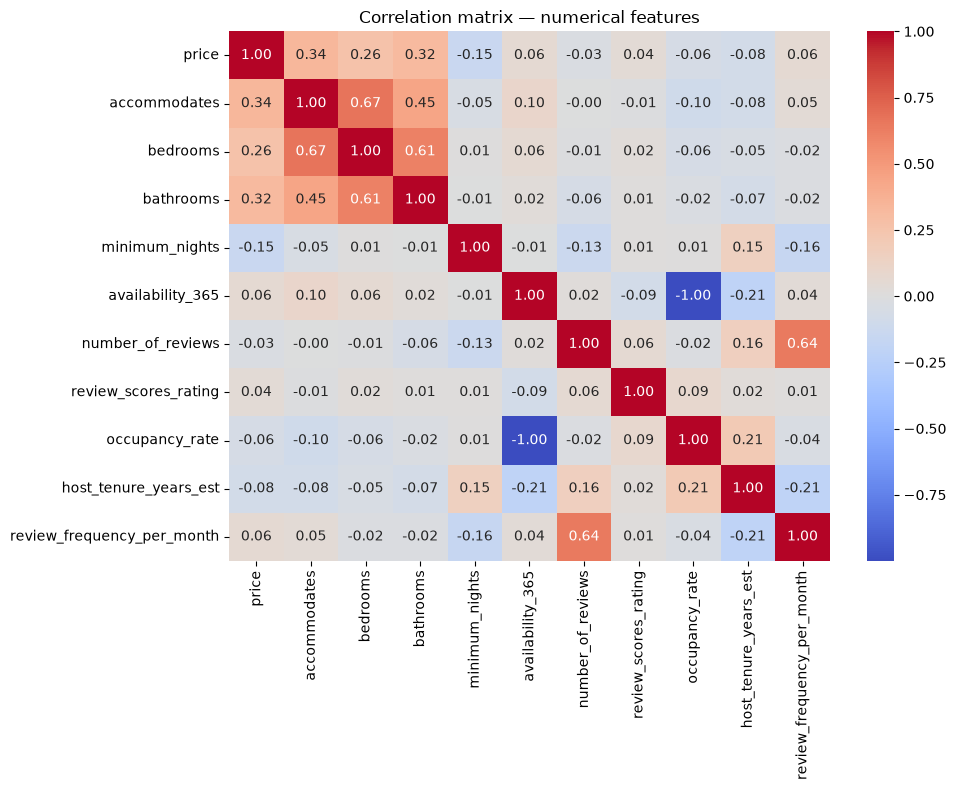

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — numerical features')
plt.tight_layout()

import os

plt.savefig("../reports/figures/fig11_correlation_matrix.png", dpi=150, bbox_inches='tight')

plt.show()

#OLS regression to quantify marginal impact on price

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

reg_data = listings[[
    'price', 'accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
    'availability_365', 'review_scores_rating', 'room_type',
    'neighbourhood_group_cleansed'
]].dropna()

print(f"Regression sample size: {len(reg_data)}")

model = smf.ols(
    'price ~ accommodates + bedrooms + bathrooms + minimum_nights + '
    'availability_365 + review_scores_rating + C(room_type) + C(neighbourhood_group_cleansed)',
    data=reg_data
).fit()

print(model.summary())

Regression sample size: 8415
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     292.0
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:15:46   Log-Likelihood:                -60726.
No. Observations:                8415   AIC:                         1.215e+05
Df Residuals:                    8401   BIC:                         1.216e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

#Multicollinearity check (VIF)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = reg_data[['accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
                       'availability_365', 'review_scores_rating']].copy()
vif_data = sm.add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df['feature'] = vif_data.columns
vif_df['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
print(vif_df)

                feature         VIF
0                 const  121.123743
1          accommodates    1.940185
2              bedrooms    2.368737
3             bathrooms    1.651581
4        minimum_nights    1.018937
5      availability_365    1.025636
6  review_scores_rating    1.011853


#Non-linear relationship check (LOWESS)

C:\Users\SKY PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


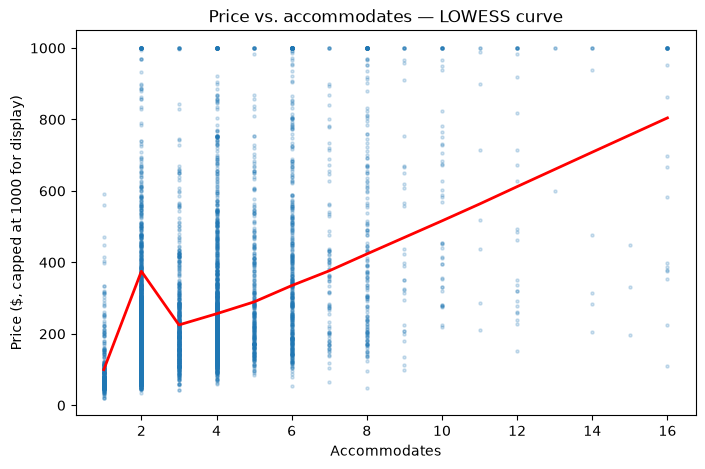

In [21]:
from statsmodels.nonparametric.smoothers_lowess import lowess

sample = reg_data.sample(min(5000, len(reg_data)), random_state=42)  # LOWESS is slow on large n
smoothed = lowess(sample['price'], sample['accommodates'], frac=0.3)

plt.figure(figsize=(8,5))
plt.scatter(sample['accommodates'], sample['price'].clip(upper=1000), s=5, alpha=0.2)
plt.plot(smoothed[:,0], smoothed[:,1], color='red', linewidth=2)
plt.xlabel('Accommodates')
plt.ylabel('Price ($, capped at 1000 for display)')
plt.title('Price vs. accommodates — LOWESS curve')

import os

plt.savefig("../reports/figures/fig12_lowess_curve.png", dpi=150, bbox_inches='tight')

plt.show()